STUDENT PLACEMENT DATASET
   CGPA  AptitudeScore  TechnicalScore  CommunicationScore Internship Branch  \
0   6.2             45              40                  50         No    CSE   
1   6.5             50              45                  52         No    ECE   
2   6.8             52              48                  55         No    CSE   
3   7.0             55              52                  58        Yes     IT   
4   7.2             58              55                  60         No    ECE   

  PlacementStatus  
0      Not Placed  
1      Not Placed  
2      Not Placed  
3          Placed  
4      Not Placed  

Dataset Shape:
(30, 7)

FEATURE TYPES
Numerical Features:
['CGPA', 'AptitudeScore', 'TechnicalScore', 'CommunicationScore']

Categorical Features:
['Internship', 'Branch']

TRAIN / VALIDATION SPLIT
Training samples: 24
Validation samples: 6


REGULARISATION COMPARISON
     C  Lasso_val_acc  Ridge_val_acc  ElasticNet_val_acc  Lasso_nonzero  Ridge_nonzero
  0.01       0.3

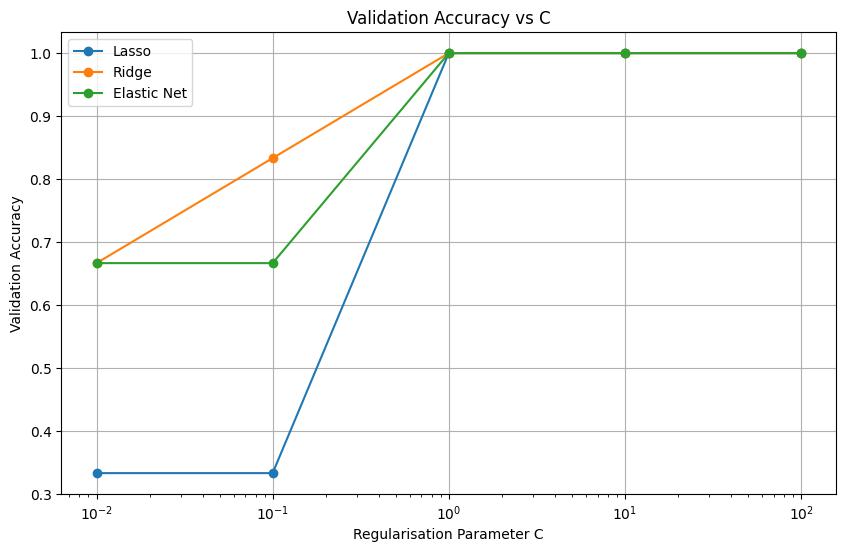

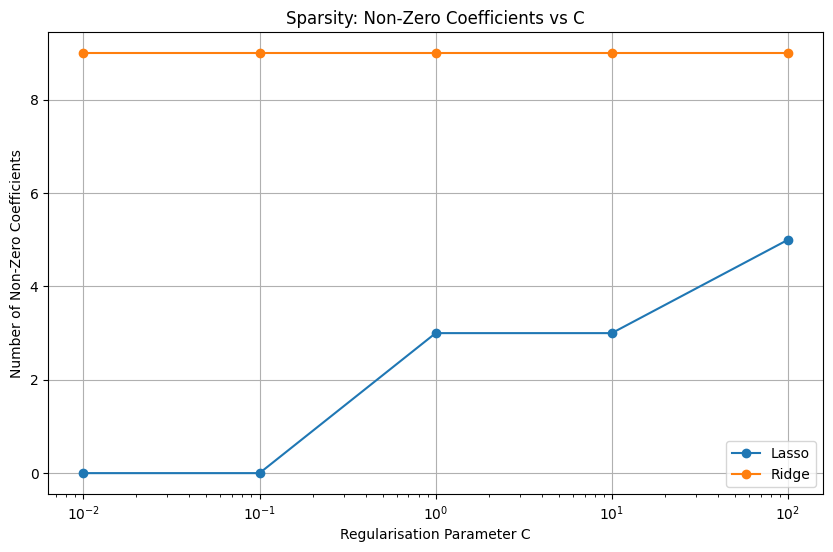

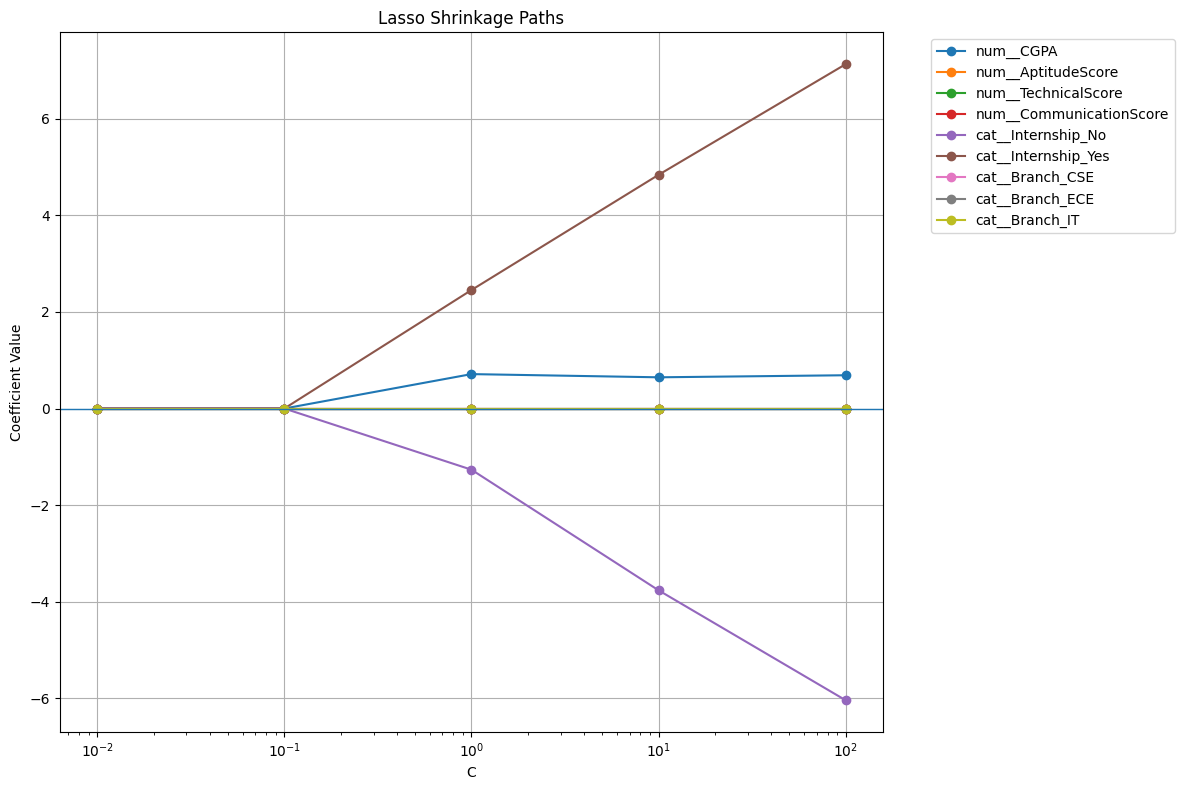

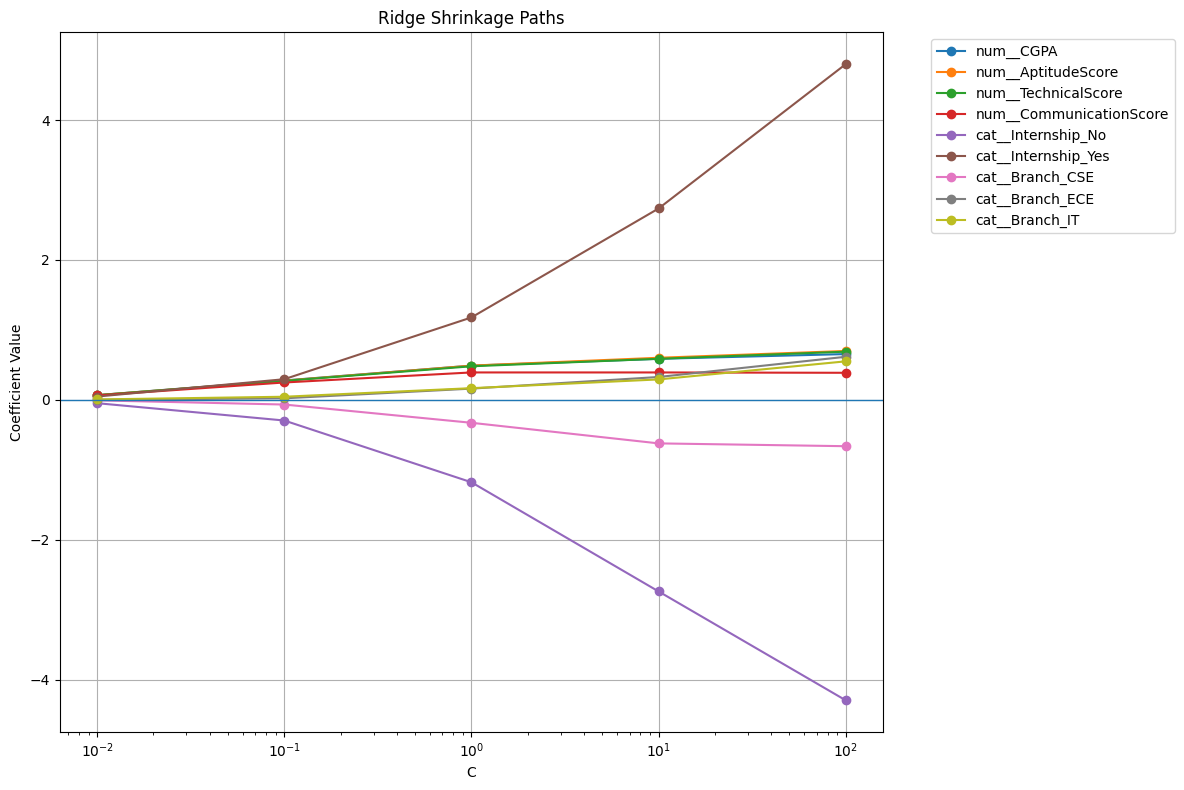



ANALYSIS

LASSO:
- Uses L1 regularisation.
- Can reduce some coefficients exactly to zero.
- Therefore it can create sparse models.
- Useful for feature selection.

RIDGE:
- Uses L2 regularisation.
- Shrinks coefficients toward zero.
- Usually keeps coefficients non-zero.
- Useful when many features contribute to prediction.

ELASTIC NET:
- Combines L1 and L2 regularisation.
- Can provide both shrinkage and sparsity.
- Controlled using the l1_ratio parameter.

C:
- C is the inverse of regularisation strength in
  LogisticRegression.
- Smaller C means stronger regularisation.
- Larger C means weaker regularisation.

SPARSITY:
- A model with fewer non-zero coefficients is more sparse.
- Lasso is particularly useful when feature selection
  is desired.

VALIDATION ACCURACY:
- Shows how accurately the model predicts unseen
  validation samples.



SESSION 5 PRACTICAL COMPLETED

Implemented:

1. Student placement dataset without external data.
2. One-Hot Encoding.
3. Feature Scaling.
4. L

In [1]:
# ================================================================
# MACHINE LEARNING PRACTICAL - SESSION 5
# ================================================================
# Topic:
# Ridge, Lasso and Elastic Net Regularisation
# Comparison across different regularisation strengths
# Validation Accuracy
# Non-zero Coefficient Count
# Shrinkage Paths
# compare_regularisation() function
# ================================================================


# ----------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ----------------------------------------------------------------
# pandas       -> DataFrame and data handling
# numpy        -> Numerical operations
# matplotlib   -> Graphs and visualization
# sklearn      -> Machine Learning
# ----------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report


# =================================================================
# 2. CREATE DATASET
# =================================================================
# We are NOT using an external dataset.
# The student placement dataset is created directly in Colab.
#
# Features:
# CGPA
# AptitudeScore
# TechnicalScore
# CommunicationScore
# Internship
# Branch
#
# Target:
# PlacementStatus
# =================================================================

data = {

    'CGPA': [
        6.2, 6.5, 6.8, 7.0, 7.2,
        7.4, 7.6, 7.8, 8.0, 8.2,
        8.4, 8.6, 8.8, 9.0, 9.2,
        9.4, 6.1, 6.7, 7.1, 7.5,
        7.9, 8.3, 8.7, 9.1, 6.4,
        6.9, 7.3, 7.7, 8.1, 8.5
    ],

    'AptitudeScore': [
        45, 50, 52, 55, 58,
        60, 62, 65, 68, 70,
        72, 75, 78, 80, 85,
        88, 42, 48, 56, 61,
        67, 73, 77, 83, 46,
        54, 59, 64, 71, 76
    ],

    'TechnicalScore': [
        40, 45, 48, 52, 55,
        58, 60, 64, 67, 70,
        72, 76, 79, 82, 86,
        90, 38, 44, 50, 57,
        63, 69, 75, 84, 43,
        49, 55, 62, 68, 74
    ],

    'CommunicationScore': [
        50, 52, 55, 58, 60,
        62, 65, 67, 70, 72,
        74, 76, 79, 82, 85,
        88, 48, 54, 57, 61,
        64, 68, 73, 80, 51,
        56, 59, 63, 69, 75
    ],

    'Internship': [
        'No', 'No', 'No', 'Yes', 'No',
        'Yes', 'Yes', 'No', 'Yes', 'Yes',
        'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
        'Yes', 'No', 'No', 'No', 'Yes',
        'Yes', 'Yes', 'Yes', 'Yes', 'No',
        'No', 'Yes', 'Yes', 'Yes', 'Yes'
    ],

    'Branch': [
        'CSE', 'ECE', 'CSE', 'IT', 'ECE',
        'CSE', 'IT', 'CSE', 'ECE', 'CSE',
        'IT', 'CSE', 'ECE', 'CSE', 'IT',
        'CSE', 'ECE', 'CSE', 'IT', 'ECE',
        'CSE', 'IT', 'CSE', 'ECE', 'IT',
        'CSE', 'ECE', 'IT', 'CSE', 'CSE'
    ],

    'PlacementStatus': [
        'Not Placed', 'Not Placed', 'Not Placed', 'Placed', 'Not Placed',
        'Placed', 'Placed', 'Not Placed', 'Placed', 'Placed',
        'Placed', 'Placed', 'Placed', 'Placed', 'Placed',
        'Placed', 'Not Placed', 'Not Placed', 'Not Placed', 'Placed',
        'Placed', 'Placed', 'Placed', 'Placed', 'Not Placed',
        'Not Placed', 'Placed', 'Placed', 'Placed', 'Placed'
    ]
}


# Convert dictionary to DataFrame
df = pd.DataFrame(data)


print("=" * 70)
print("STUDENT PLACEMENT DATASET")
print("=" * 70)

print(df.head())

print("\nDataset Shape:")
print(df.shape)


# =================================================================
# 3. SEPARATE FEATURES AND TARGET
# =================================================================

X = df.drop(
    columns=['PlacementStatus']
)

y = df['PlacementStatus']


# =================================================================
# 4. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# =================================================================
#
# Numerical features will be scaled using StandardScaler.
#
# Categorical features will be converted using OneHotEncoder.
# =================================================================

numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=['object']
).columns.tolist()


print("\n" + "=" * 70)
print("FEATURE TYPES")
print("=" * 70)

print("Numerical Features:")
print(numerical_cols)

print("\nCategorical Features:")
print(categorical_cols)


# =================================================================
# 5. CREATE PREPROCESSING PIPELINE
# =================================================================
#
# StandardScaler:
#     Scales numerical features.
#
# OneHotEncoder:
#     Converts categorical features into numerical columns.
# =================================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            'num',
            StandardScaler(),
            numerical_cols
        ),

        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_cols
        )
    ]
)


# =================================================================
# 6. TRAIN / VALIDATION SPLIT
# =================================================================

X_train, X_val, y_train, y_val = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)


print("\n" + "=" * 70)
print("TRAIN / VALIDATION SPLIT")
print("=" * 70)

print("Training samples:",
      len(X_train))

print("Validation samples:",
      len(X_val))


# =================================================================
# 7. UNDERSTANDING REGULARISATION
# =================================================================
#
# Regularisation reduces overly large model coefficients.
#
# L1 = Lasso
#     Can make coefficients exactly zero.
#     Therefore it creates sparse models.
#
# L2 = Ridge
#     Shrinks coefficients toward zero.
#     Usually does not make them exactly zero.
#
# Elastic Net
#     Combines L1 and L2 regularisation.
#
# C:
#     In LogisticRegression, C is the inverse of regularisation
#     strength.
#
# Small C  -> stronger regularisation
# Large C  -> weaker regularisation
# =================================================================


# C values to test
C_values = [
    0.01,
    0.1,
    1,
    10,
    100
]


# =================================================================
# 8. FUNCTION TO COUNT NON-ZERO COEFFICIENTS
# =================================================================
#
# A coefficient is considered non-zero if its absolute value
# is greater than a very small threshold.
#
# This is used to measure model sparsity.
# =================================================================

def count_nonzero_coefficients(model):

    coefficients = (
        model
        .named_steps['classifier']
        .coef_
    )

    return np.sum(
        np.abs(coefficients) > 1e-6
    )


# =================================================================
# 9. compare_regularisation() FUNCTION
# =================================================================
#
# This is the main function required by the practical.
#
# It:
#
# 1. Takes training and validation data
# 2. Tests different C values
# 3. Creates Lasso, Ridge and Elastic Net models
# 4. Calculates validation accuracy
# 5. Counts non-zero coefficients
# 6. Stores everything in a DataFrame
#
# Output columns:
#
# C
# Lasso_val_acc
# Ridge_val_acc
# ElasticNet_val_acc
# Lasso_nonzero
# Ridge_nonzero
# =================================================================

def compare_regularisation(
    X_train,
    y_train,
    X_val,
    y_val,
    C_values
):

    results = []


    # Loop through every C value
    for C in C_values:


        # --------------------------------------------------------
        # LASSO
        # L1 regularisation
        # --------------------------------------------------------

        lasso_model = Pipeline([

            (
                'preprocessor',
                preprocessor
            ),

            (
                'classifier',
                LogisticRegression(
                    penalty='l1',
                    solver='liblinear',
                    C=C,
                    max_iter=2000
                )
            )
        ])


        # Train Lasso
        lasso_model.fit(
            X_train,
            y_train
        )


        # Predict validation set
        lasso_prediction = lasso_model.predict(
            X_val
        )


        # Calculate validation accuracy
        lasso_accuracy = accuracy_score(
            y_val,
            lasso_prediction
        )


        # Count non-zero coefficients
        lasso_nonzero = count_nonzero_coefficients(
            lasso_model
        )


        # --------------------------------------------------------
        # RIDGE
        # L2 regularisation
        # --------------------------------------------------------

        ridge_model = Pipeline([

            (
                'preprocessor',
                preprocessor
            ),

            (
                'classifier',
                LogisticRegression(
                    penalty='l2',
                    solver='lbfgs',
                    C=C,
                    max_iter=2000
                )
            )
        ])


        # Train Ridge
        ridge_model.fit(
            X_train,
            y_train
        )


        # Predict validation set
        ridge_prediction = ridge_model.predict(
            X_val
        )


        # Calculate validation accuracy
        ridge_accuracy = accuracy_score(
            y_val,
            ridge_prediction
        )


        # Count non-zero coefficients
        ridge_nonzero = count_nonzero_coefficients(
            ridge_model
        )


        # --------------------------------------------------------
        # ELASTIC NET
        # --------------------------------------------------------
        #
        # Elastic Net combines L1 and L2.
        #
        # l1_ratio = 0.5 means:
        # approximately equal contribution of L1 and L2.
        # --------------------------------------------------------

        elastic_model = Pipeline([

            (
                'preprocessor',
                preprocessor
            ),

            (
                'classifier',
                LogisticRegression(
                    penalty='elasticnet',
                    solver='saga',
                    C=C,
                    l1_ratio=0.5,
                    max_iter=5000
                )
            )
        ])


        # Train Elastic Net
        elastic_model.fit(
            X_train,
            y_train
        )


        # Predict validation data
        elastic_prediction = elastic_model.predict(
            X_val
        )


        # Calculate validation accuracy
        elastic_accuracy = accuracy_score(
            y_val,
            elastic_prediction
        )


        # --------------------------------------------------------
        # Store results
        # --------------------------------------------------------

        results.append({

            'C': C,

            'Lasso_val_acc':
            lasso_accuracy,

            'Ridge_val_acc':
            ridge_accuracy,

            'ElasticNet_val_acc':
            elastic_accuracy,

            'Lasso_nonzero':
            lasso_nonzero,

            'Ridge_nonzero':
            ridge_nonzero
        })


    # Convert results to DataFrame
    return pd.DataFrame(results)


# =================================================================
# 10. RUN compare_regularisation()
# =================================================================

results_df = compare_regularisation(

    X_train,
    y_train,

    X_val,
    y_val,

    C_values
)


# =================================================================
# 11. DISPLAY RESULTS
# =================================================================

print("\n")
print("=" * 90)
print("REGULARISATION COMPARISON")
print("=" * 90)

print(results_df.to_string(index=False))


# =================================================================
# 12. VALIDATION ACCURACY VS C
# =================================================================
#
# This graph shows how prediction accuracy changes when
# regularisation strength changes.
#
# Remember:
# Smaller C = stronger regularisation
# Larger C  = weaker regularisation
# =================================================================

plt.figure(figsize=(10, 6))


plt.plot(
    results_df['C'],
    results_df['Lasso_val_acc'],
    marker='o',
    label='Lasso'
)


plt.plot(
    results_df['C'],
    results_df['Ridge_val_acc'],
    marker='o',
    label='Ridge'
)


plt.plot(
    results_df['C'],
    results_df['ElasticNet_val_acc'],
    marker='o',
    label='Elastic Net'
)


plt.xscale('log')


plt.xlabel(
    'Regularisation Parameter C'
)


plt.ylabel(
    'Validation Accuracy'
)


plt.title(
    'Validation Accuracy vs C'
)


plt.legend()


plt.grid(True)


plt.show()


# =================================================================
# 13. NON-ZERO COEFFICIENT COUNT
# =================================================================
#
# This graph demonstrates SPARSITY.
#
# Lasso can set coefficients exactly to zero.
#
# Ridge normally keeps coefficients non-zero while shrinking them.
#
# Elastic Net can also produce sparse coefficients because it
# contains an L1 component.
# =================================================================

plt.figure(figsize=(10, 6))


plt.plot(
    results_df['C'],
    results_df['Lasso_nonzero'],
    marker='o',
    label='Lasso'
)


plt.plot(
    results_df['C'],
    results_df['Ridge_nonzero'],
    marker='o',
    label='Ridge'
)


plt.xscale('log')


plt.xlabel(
    'Regularisation Parameter C'
)


plt.ylabel(
    'Number of Non-Zero Coefficients'
)


plt.title(
    'Sparsity: Non-Zero Coefficients vs C'
)


plt.legend()


plt.grid(True)


plt.show()


# =================================================================
# 14. SHRINKAGE PATHS - LASSO
# =================================================================
#
# A shrinkage path shows how model coefficients change as C changes.
#
# Strong regularisation:
#     coefficients become smaller.
#
# Weak regularisation:
#     coefficients can become larger.
# =================================================================

lasso_coefficients = []


for C in C_values:

    lasso_model = Pipeline([

        (
            'preprocessor',
            preprocessor
        ),

        (
            'classifier',
            LogisticRegression(
                penalty='l1',
                solver='liblinear',
                C=C,
                max_iter=2000
            )
        )
    ])


    lasso_model.fit(
        X_train,
        y_train
    )


    coefficients = (
        lasso_model
        .named_steps['classifier']
        .coef_[0]
    )


    lasso_coefficients.append(
        coefficients
    )


lasso_coefficients = np.array(
    lasso_coefficients
)


# Get feature names
feature_names = (
    lasso_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)


# Plot Lasso shrinkage paths

plt.figure(figsize=(12, 8))


for i in range(
    lasso_coefficients.shape[1]
):

    plt.plot(
        C_values,
        lasso_coefficients[:, i],
        marker='o',
        label=feature_names[i]
    )


plt.xscale('log')


plt.xlabel(
    'C'
)


plt.ylabel(
    'Coefficient Value'
)


plt.title(
    'Lasso Shrinkage Paths'
)


plt.axhline(
    0,
    linewidth=1
)


plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)


plt.grid(True)


plt.tight_layout()


plt.show()


# =================================================================
# 15. SHRINKAGE PATHS - RIDGE
# =================================================================

ridge_coefficients = []


for C in C_values:

    ridge_model = Pipeline([

        (
            'preprocessor',
            preprocessor
        ),

        (
            'classifier',
            LogisticRegression(
                penalty='l2',
                solver='lbfgs',
                C=C,
                max_iter=2000
            )
        )
    ])


    ridge_model.fit(
        X_train,
        y_train
    )


    coefficients = (
        ridge_model
        .named_steps['classifier']
        .coef_[0]
    )


    ridge_coefficients.append(
        coefficients
    )


ridge_coefficients = np.array(
    ridge_coefficients
)


# Plot Ridge shrinkage paths

plt.figure(figsize=(12, 8))


for i in range(
    ridge_coefficients.shape[1]
):

    plt.plot(
        C_values,
        ridge_coefficients[:, i],
        marker='o',
        label=feature_names[i]
    )


plt.xscale('log')


plt.xlabel(
    'C'
)


plt.ylabel(
    'Coefficient Value'
)


plt.title(
    'Ridge Shrinkage Paths'
)


plt.axhline(
    0,
    linewidth=1
)


plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)


plt.grid(True)


plt.tight_layout()


plt.show()


# =================================================================
# 16. FINAL ANALYSIS
# =================================================================

print("\n")
print("=" * 90)
print("ANALYSIS")
print("=" * 90)

print("""
LASSO:
- Uses L1 regularisation.
- Can reduce some coefficients exactly to zero.
- Therefore it can create sparse models.
- Useful for feature selection.

RIDGE:
- Uses L2 regularisation.
- Shrinks coefficients toward zero.
- Usually keeps coefficients non-zero.
- Useful when many features contribute to prediction.

ELASTIC NET:
- Combines L1 and L2 regularisation.
- Can provide both shrinkage and sparsity.
- Controlled using the l1_ratio parameter.

C:
- C is the inverse of regularisation strength in
  LogisticRegression.
- Smaller C means stronger regularisation.
- Larger C means weaker regularisation.

SPARSITY:
- A model with fewer non-zero coefficients is more sparse.
- Lasso is particularly useful when feature selection
  is desired.

VALIDATION ACCURACY:
- Shows how accurately the model predicts unseen
  validation samples.
""")


# =================================================================
# 17. FINAL PRACTICAL SUMMARY
# =================================================================

print("\n")
print("=" * 90)
print("SESSION 5 PRACTICAL COMPLETED")
print("=" * 90)

print("""
Implemented:

1. Student placement dataset without external data.
2. One-Hot Encoding.
3. Feature Scaling.
4. Lasso Logistic Regression.
5. Ridge Logistic Regression.
6. Elastic Net Logistic Regression.
7. Multiple regularisation strengths using C.
8. compare_regularisation() function.
9. Validation accuracy comparison.
10. Non-zero coefficient analysis.
11. Lasso shrinkage paths.
12. Ridge shrinkage paths.
13. Regularisation and sparsity analysis.
""")